In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置 matplotlib 绘图样式，使其更美观
plt.style.use('ggplot')


plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
print("库导入成功！")

库导入成功！


# iGEM 数模组面试 - A 方案：SIR 模型分析

**面试者：宗家锐**

---

### 任务 (1): 实现龙格-库塔法 (Runge-Kutta method)

我选择实现四阶龙格-库塔法 (RK4)，因为它比一阶欧拉法有更高的精度和稳定性。

In [2]:
def sir_model_derivatives(y, t, N, beta, gamma):
    """
    定义 SIR 模型的微分方程组
    y = [S, I, R]
    返回 [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    dS_dt = -beta * S * I / N
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I
    return np.array([dS_dt, dI_dt, dR_dt])

def runge_kutta_4(func, y0, t_points, args=()):
    """
    从零实现的四阶龙格-库塔 (RK4) 求解器
    :param func: 导数函数 (例如 sir_model_derivatives)
    :param y0: 初始条件 [S0, I0, R0]
    :param t_points: 时间点数组
    :param args: 传递给 func 的额外参数 (N, beta, gamma)
    :return: 求解结果数组
    """
    n = len(t_points)
    m = len(y0)
    y_results = np.zeros((n, m))
    y_results[0] = y0
    
    for i in range(n - 1):
        h = t_points[i+1] - t_points[i]  # 时间步长
        y_current = y_results[i]
        t_current = t_points[i]
        
        k1 = func(y_current, t_current, *args)
        k2 = func(y_current + h/2 * k1, t_current + h/2, *args)
        k3 = func(y_current + h/2 * k2, t_current + h/2, *args)
        k4 = func(y_current + h * k3, t_current + h, *args)
        
        y_next = y_current + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y_results[i+1] = y_next
        
    return y_results

print("RK4 求解器和 SIR 模型定义成功！")

RK4 求解器和 SIR 模型定义成功！


### 任务 (2) & (3): 基础模拟与绘图 ($R_0=5$)

设置 $S(0)=990$, $I(0)=10$, $R(0)=0$，参数 $\beta=0.5$, $\gamma=0.1$ (即 $R_0=5$)。模拟 0-100 天。

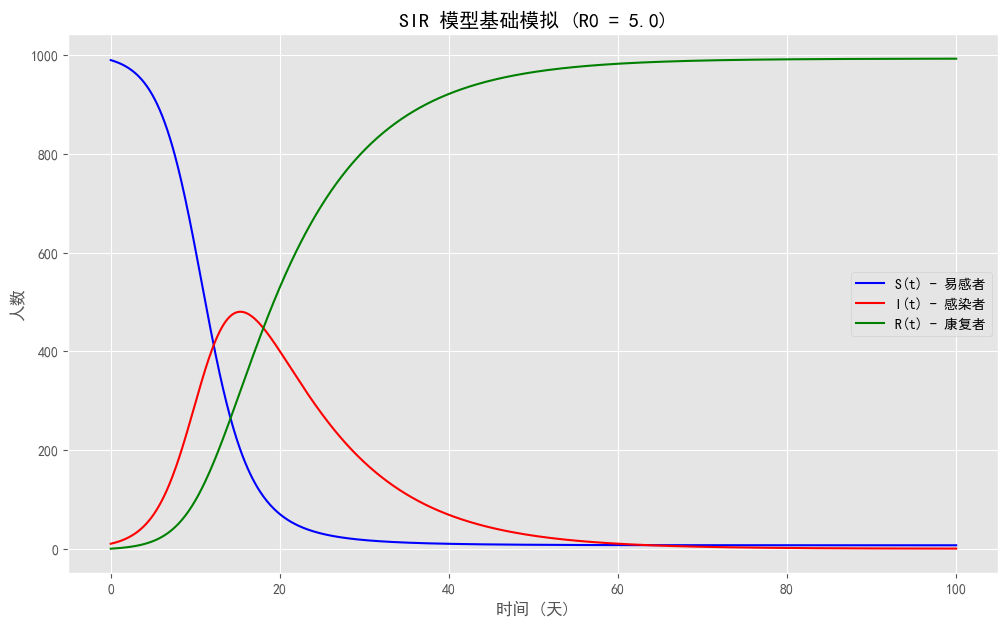

In [3]:
# 1. 设置参数和初始条件
S0 = 990
I0 = 10
R0_init = 0
N = S0 + I0 + R0_init  # 总人口 1000
beta = 0.5
gamma = 0.1
R_nought = beta / gamma  # 基本再生数 R0

# 2. 设置时间范围 (0-100 天)
t_start = 0
t_end = 100
h = 0.1  # 时间步长
t_points = np.arange(t_start, t_end + h, h)

# 3. 求解
y0 = [S0, I0, R0_init]
args = (N, beta, gamma)
solution = runge_kutta_4(sir_model_derivatives, y0, t_points, args)

# 4. 提取 S, I, R
S_t = solution[:, 0]
I_t = solution[:, 1]
R_t = solution[:, 2]

# 5. 绘图
plt.figure(figsize=(12, 7))
plt.plot(t_points, S_t, label='S(t) - 易感者', color='blue')
plt.plot(t_points, I_t, label='I(t) - 感染者', color='red')
plt.plot(t_points, R_t, label='R(t) - 康复者', color='green')
plt.title(f'SIR 模型基础模拟 (R0 = {R_nought})')
plt.xlabel('时间 (天)')
plt.ylabel('人数')
plt.legend()
plt.grid(True)
plt.show()

### 任务 (4): 分析 $R_0$ 的影响与 $R_0=1$ 的意义

#### $R_0=1$ 的数学意义
我们关注感染人数 $I(t)$ 的变化，即 $\frac{dI}{dt}$：
$$\frac{dI}{dt} = \beta \frac{S}{N} I - \gamma I = \left( \beta \frac{S}{N} - \gamma \right) I$$

在疫情**初期**，$S \approx N$，所以 $\frac{S}{N} \approx 1$。
此时，方程近似为：
$$\frac{dI}{dt} \approx (\beta - \gamma) I$$

提出 $\gamma$，并代入 $R_0 = \frac{\beta}{\gamma}$：
$$\frac{dI}{dt} \approx \gamma \left( \frac{\beta}{\gamma} - 1 \right) I = \gamma (R_0 - 1) I$$

这个式子清楚地表明：
* **当 $R_0 > 1$ 时**：$\frac{dI}{dt} > 0$，$I(t)$ 呈指数增长，**疫情爆发**。
* **当 $R_0 < 1$ 时**：$\frac{dI}{dt} < 0$，$I(t)$ 从一开始就下降，**疫情自动消亡**。
* **当 $R_0 = 1$ 时**：$\frac{dI}{dt} \approx 0$，感染人数在初期保持不变，这是疫情能否爆发的**临界阈值**。

#### 不同 $R_0$ 值的影响
现在我们绘制 $R_0$ 分别为 0.5, 1.5, 3.0, 5.0 时，$I(t)$ 的变化曲线。

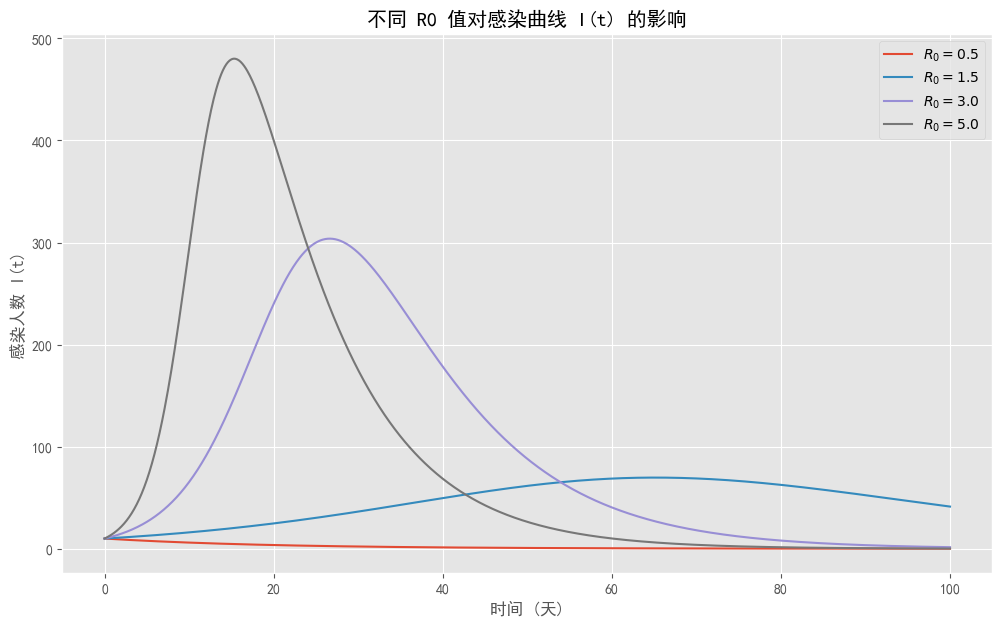

In [4]:
R0_values = [0.5, 1.5, 3.0, 5.0]
gamma_fixed = 0.1
y0 = [S0, I0, R0_init]  # 初始条件不变
# t_points 在上个单元格已定义，可直接使用

plt.figure(figsize=(12, 7))

for R0_val in R0_values:
    beta_val = R0_val * gamma_fixed  # R0 = beta / gamma => beta = R0 * gamma
    args = (N, beta_val, gamma_fixed)
    
    solution = runge_kutta_4(sir_model_derivatives, y0, t_points, args)
    I_t_current = solution[:, 1]  # 只关心感染人数 I(t)
    
    plt.plot(t_points, I_t_current, label=f'$R_0 = {R0_val}$')

plt.title('不同 R0 值对感染曲线 I(t) 的影响')
plt.xlabel('时间 (天)')
plt.ylabel('感染人数 I(t)')
plt.legend()
plt.grid(True)
plt.show()

### 任务 (5): 模拟干预措施

为了模拟在 $t=20$ 天时 $\beta$ 降低 50% 的情况，我采用了一个更灵活的方案：将 $\beta$ 定义为一个随时间 $t$ 变化的函数 `get_beta(t)`。
我的 RK4 求解器和导数函数被设计为在每一步计算时都去调用这个函数，获取当前的 $\beta$ 值。

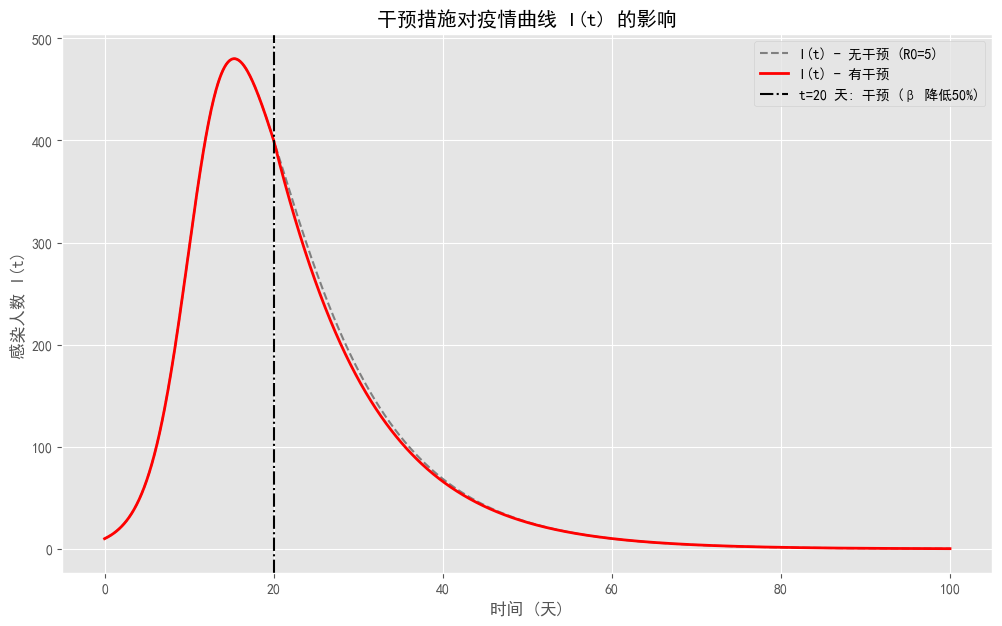

In [5]:
# 1. 定义一个“随时间变化”的 beta 函数
beta_initial = 0.5
intervention_time = 20
intervention_factor = 0.5  # beta 降低 50%

def get_beta(t):
    """根据时间返回 beta 值"""
    if t < intervention_time:
        return beta_initial
    else:
        return beta_initial * intervention_factor

# 2. 新版本的导数函数，它在内部调用 get_beta(t)
def sir_model_derivatives_intervention(y, t, N, gamma):
    S, I, R = y
    # 核心：beta 是随时间 t 变化的
    current_beta = get_beta(t)
    
    dS_dt = -current_beta * S * I / N
    dI_dt = current_beta * S * I / N - gamma * I
    dR_dt = gamma * I
    return np.array([dS_dt, dI_dt, dR_dt])

# 3. 求解“有干预”的情况
gamma = 0.1
y0 = [S0, I0, R0_init]
# t_points 依然可用

# 注意：args 现在只包含 N 和 gamma
args_intervention = (N, gamma)

solution_intervention = runge_kutta_4(
    sir_model_derivatives_intervention, 
    y0, 
    t_points, 
    args=args_intervention
)
I_t_intervention = solution_intervention[:, 1]

# 4. 绘图对比
plt.figure(figsize=(12, 7))
# 绘制无干预曲线 (虚线) - I_t 是单元格5算出来的
plt.plot(t_points, I_t, label='I(t) - 无干预 (R0=5)', color='gray', linestyle='--')
# 绘制有干预曲线 (实线)
plt.plot(t_points, I_t_intervention, label='I(t) - 有干预', color='red', linewidth=2)

# 标记干预点
plt.axvline(x=intervention_time, color='black', linestyle='-.', label=f't=20 天: 干预 (β 降低50%)')

plt.title('干预措施对疫情曲线 I(t) 的影响')
plt.xlabel('时间 (天)')
plt.ylabel('感染人数 I(t)')
plt.legend()
plt.grid(True)
plt.show()